# 04 · Segmentation Modelling
**Input**: `data/processed/rfm_scaled.csv` (11 scaled features, 1 row = 1 customer)  
**Output**: cluster labels saved to `data/processed/rfm_clustered.csv` · models in `models/`

---
## Algorithm comparison plan

| Algorithm | Strength | Weakness |
|-----------|----------|----------|
| **K-Means** | Fast, interpretable centroids | Assumes spherical clusters |
| **Hierarchical** | No k needed; exposes hierarchy | O(n²) — not for millions |
| **DBSCAN** | Finds arbitrary shapes; marks noise | Sensitive to eps / min_samples |
| **GMM** | Soft assignments; elliptical clusters | Can overfit with full covariance |

We run all four, compare on three metrics, then select the best for production.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
import joblib, warnings
warnings.filterwarnings('ignore')

# sklearn — all standard library calls, no custom classes
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)

sns.set_theme(style='whitegrid', palette='husl')

PROC_DIR  = Path('../data/processed')
MODEL_DIR = Path('../models')
PLOT_DIR  = Path('../docs/eda_plots')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

rfm     = pd.read_csv(PROC_DIR / 'rfm_features.csv',  index_col=0)
X       = pd.read_csv(PROC_DIR / 'rfm_scaled.csv',    index_col=0)
RANDOM  = 42
print(f'Customers: {len(X):,} | Features: {X.shape[1]}')
print(f'Features: {list(X.columns)}')


Customers: 3,155 | Features: 11
Features: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TenureDays', 'CLV', 'UniqueProducts', 'AvgBasketSize', 'PurchaseFreqMonthly', 'MonthlySpendCV', 'WeekendShopperRatio']


## 2. PCA — visualise in 2-D before clustering
We use PCA only for visualisation. Clustering runs on the full 11-dimensional space.

PCA 2-D explains 68.0% of variance


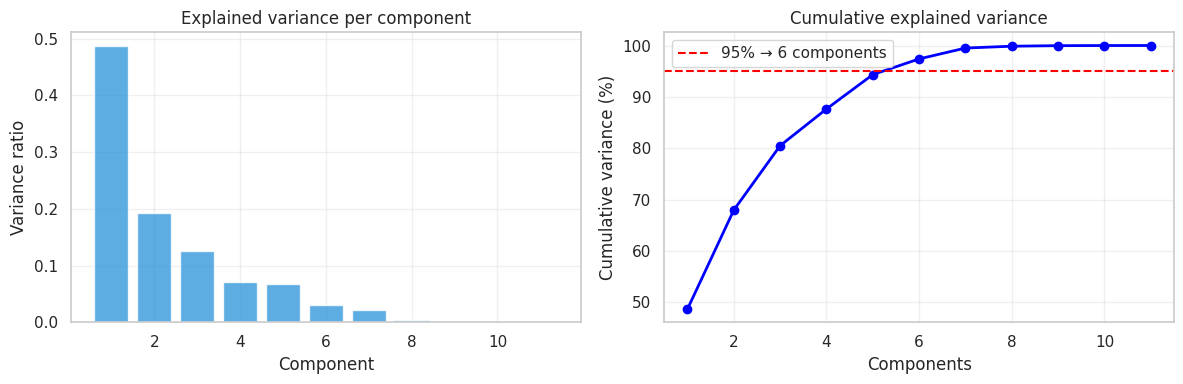

Components needed for 95% variance: 6


In [2]:
pca2 = PCA(n_components=2, random_state=RANDOM)
X_2d = pca2.fit_transform(X)

print(f'PCA 2-D explains {pca2.explained_variance_ratio_.sum():.1%} of variance')

# Scree plot — how many components for 95%?
pca_full = PCA().fit(X)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n95      = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#3498DB', alpha=0.8)
axes[0].set_title('Explained variance per component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance ratio')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cum_var)+1), cum_var * 100, 'bo-', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label=f'95% → {n95} components')
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '16_pca_scree.png', dpi=150)
plt.show()
print(f'Components needed for 95% variance: {n95}')


## 3. Elbow method — find optimal k for K-Means

In [3]:
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=RANDOM)
    silhouettes.append(sil)
    print(f'  k={k:2d} | inertia={km.inertia_:>10,.1f} | silhouette={sil:.4f}')

# Knee detection via second derivative
deltas  = np.diff(inertias)
knee_k  = list(K_RANGE)[np.argmax(np.diff(deltas)) + 1]
best_k  = list(K_RANGE)[np.argmax(silhouettes)]
print(f'\nElbow knee → k={knee_k} | Best silhouette → k={best_k}')


  k= 2 | inertia=  21,611.8 | silhouette=0.3820


  k= 3 | inertia=  18,933.0 | silhouette=0.1882


  k= 4 | inertia=  16,006.7 | silhouette=0.2470


  k= 5 | inertia=  13,909.7 | silhouette=0.1980


  k= 6 | inertia=  12,316.8 | silhouette=0.1963


  k= 7 | inertia=  11,508.9 | silhouette=0.1730


  k= 8 | inertia=  10,924.7 | silhouette=0.1658


  k= 9 | inertia=  10,471.8 | silhouette=0.1604


  k=10 | inertia=  10,037.7 | silhouette=0.1526

Elbow knee → k=4 | Best silhouette → k=2


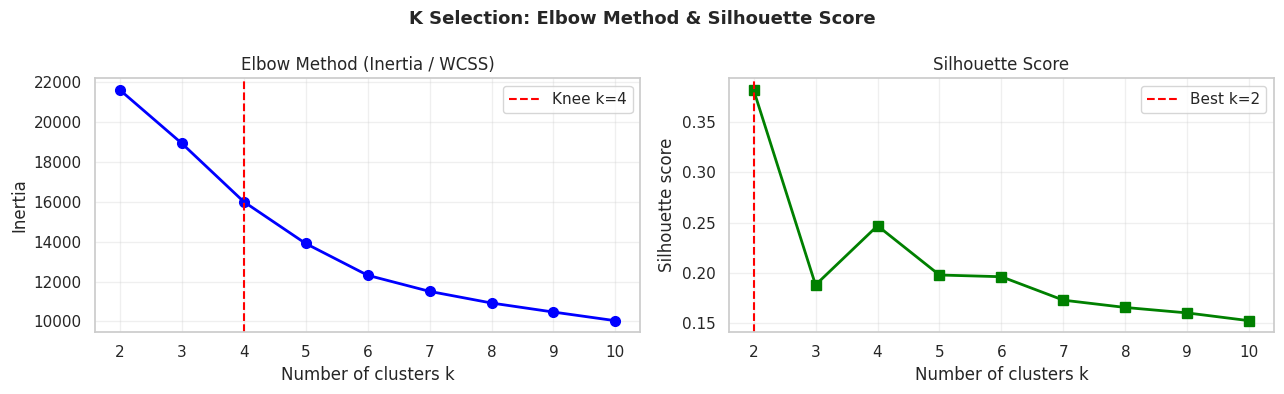

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('K Selection: Elbow Method & Silhouette Score', fontsize=13, fontweight='bold')

k_list = list(K_RANGE)
axes[0].plot(k_list, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(knee_k, color='red', linestyle='--', label=f'Knee k={knee_k}')
axes[0].set_title('Elbow Method (Inertia / WCSS)')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_list, silhouettes, 'gs-', linewidth=2, markersize=7)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '01_elbow_silhouette.png', dpi=150)
plt.show()


## 4. Fit all four algorithms (k=4)

In [5]:
K = 4   # chosen from elbow + silhouette analysis

# ── K-Means ──────────────────────────────────────────────────────────────
km_model  = KMeans(n_clusters=K, init='k-means++', n_init=10,
                   max_iter=300, random_state=RANDOM)
km_labels = km_model.fit_predict(X)
print(f'K-Means   | inertia={km_model.inertia_:>10,.1f} | clusters={np.bincount(km_labels).tolist()}')

# ── Hierarchical (Ward linkage) ───────────────────────────────────────────
hc_model  = AgglomerativeClustering(n_clusters=K, linkage='ward')
hc_labels = hc_model.fit_predict(X)
print(f'Hierarch. | clusters={np.bincount(hc_labels).tolist()}')

# ── DBSCAN ───────────────────────────────────────────────────────────────
db_model  = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
db_labels = db_model.fit_predict(X)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
print(f'DBSCAN    | clusters={n_clusters_db} | noise points={n_noise:,}')

# ── Gaussian Mixture Model ────────────────────────────────────────────────
gmm_model  = GaussianMixture(n_components=K, covariance_type='full',
                              max_iter=200, random_state=RANDOM)
gmm_labels = gmm_model.fit_predict(X)
print(f'GMM       | BIC={gmm_model.bic(X.values):>10,.1f} | clusters={np.bincount(gmm_labels).tolist()}')


K-Means   | inertia=  16,006.7 | clusters=[620, 1959, 567, 9]


Hierarch. | clusters=[1226, 1496, 9, 424]
DBSCAN    | clusters=2 | noise points=3,143


GMM       | BIC= -10,578.0 | clusters=[920, 1841, 385, 9]


## 5. Evaluation metrics comparison

In [6]:
def eval_metrics(X_arr, labels, name):
    mask = labels >= 0   # exclude DBSCAN noise
    Xm, lm = X_arr[mask], labels[mask]
    if len(set(lm)) < 2:
        return {'Model': name, 'Silhouette': np.nan,
                'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan,
                'N_clusters': len(set(lm))}
    return {
        'Model':             name,
        'Silhouette':        round(silhouette_score(Xm, lm, sample_size=min(5000,len(Xm)), random_state=RANDOM), 4),
        'Davies-Bouldin':    round(davies_bouldin_score(Xm, lm), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(Xm, lm), 1),
        'N_clusters':        len(set(lm)),
    }

X_arr = X.values
results = pd.DataFrame([
    eval_metrics(X_arr, km_labels, 'K-Means'),
    eval_metrics(X_arr, hc_labels, 'Hierarchical'),
    eval_metrics(X_arr, db_labels, 'DBSCAN'),
    eval_metrics(X_arr, gmm_labels,'GMM'),
]).set_index('Model')

print(results.to_string())
print('\n★ Best Silhouette → ', results['Silhouette'].idxmax())
print('★ Best Davies-Bouldin → ', results['Davies-Bouldin'].idxmin())
print('★ Best Calinski-Harabasz → ', results['Calinski-Harabasz'].idxmax())


              Silhouette  Davies-Bouldin  Calinski-Harabasz  N_clusters
Model                                                                  
K-Means           0.2470          1.2413             1014.9           4
Hierarchical      0.1634          1.4594              910.4           4
DBSCAN            0.8493          0.1978              235.4           2
GMM               0.1204          1.6367              538.5           4

★ Best Silhouette →  DBSCAN
★ Best Davies-Bouldin →  DBSCAN
★ Best Calinski-Harabasz →  K-Means


## 6. Model comparison bar chart

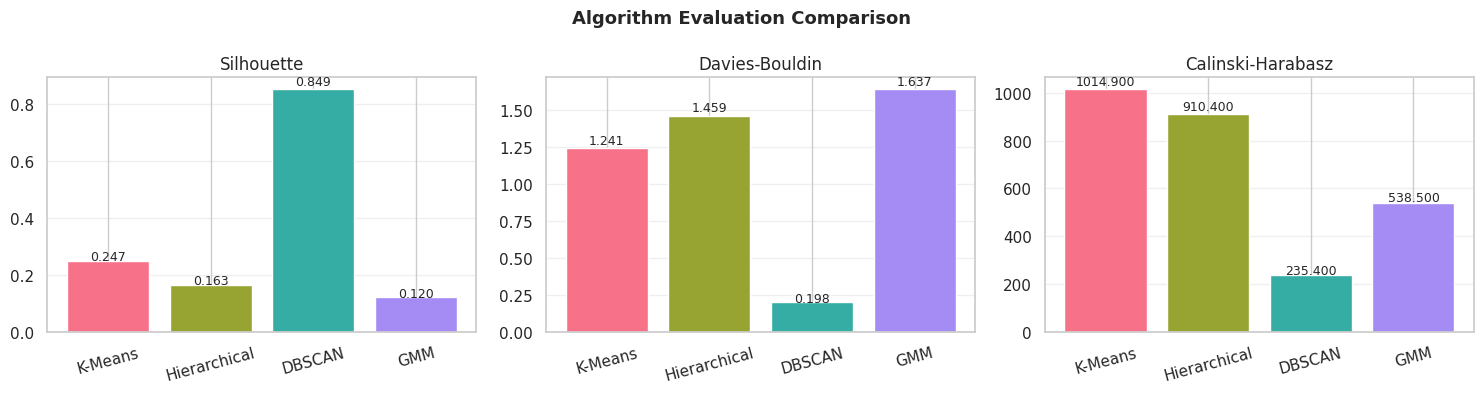

In [7]:
metrics = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Algorithm Evaluation Comparison', fontsize=13, fontweight='bold')
colors = sns.color_palette('husl', 4)

for ax, metric in zip(axes, metrics):
    vals = results[metric].dropna().astype(float)
    bars = ax.bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='white')
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / '04_model_comparison.png', dpi=150)
plt.show()


## 7. PCA 2-D cluster scatter — all 4 algorithms

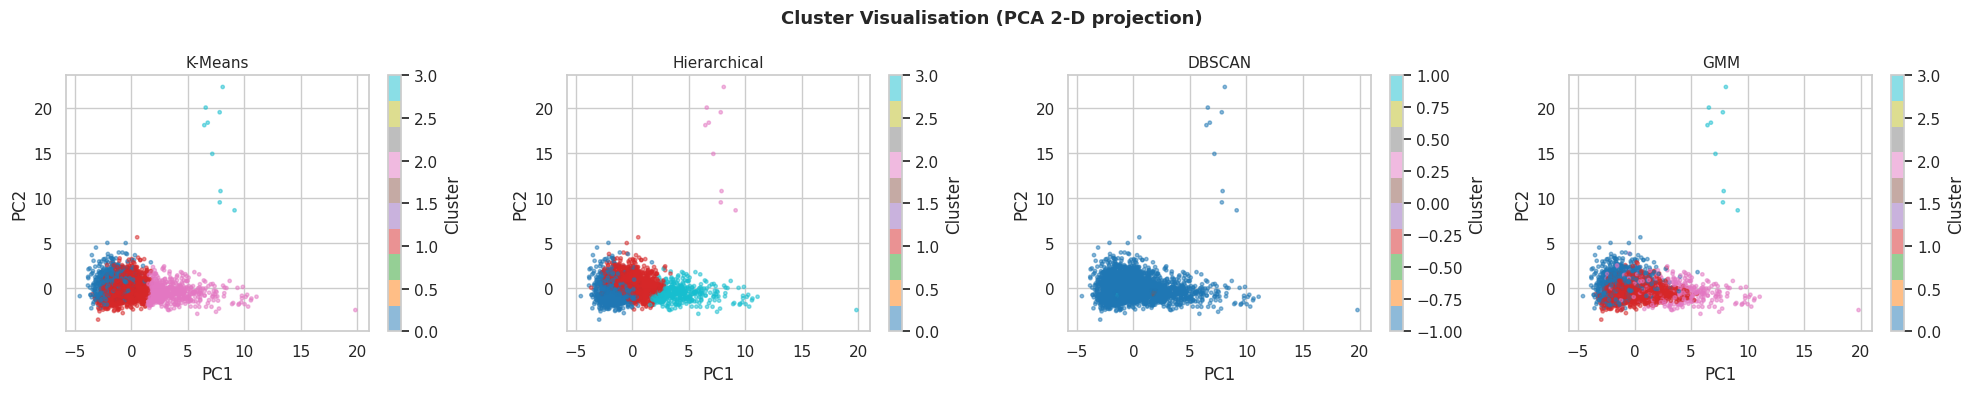

In [8]:
all_labels = {'K-Means': km_labels, 'Hierarchical': hc_labels,
              'DBSCAN': db_labels, 'GMM': gmm_labels}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Cluster Visualisation (PCA 2-D projection)', fontsize=13, fontweight='bold')

for ax, (name, labels) in zip(axes, all_labels.items()):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                    cmap='tab10', s=6, alpha=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.colorbar(sc, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig(PLOT_DIR / '03_pca_clusters.png', dpi=150)
plt.show()


## 8. Silhouette diagram for K-Means

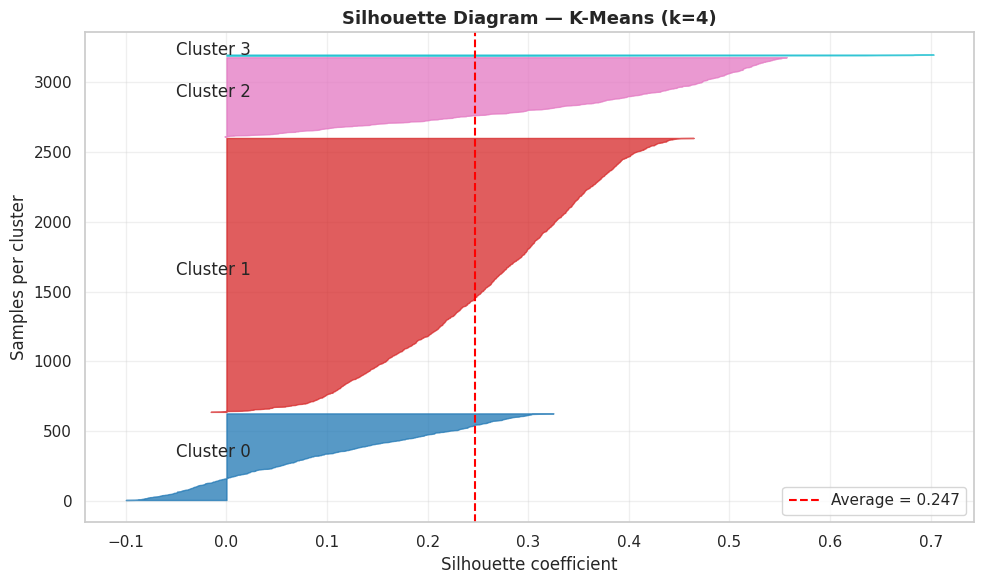

In [9]:
sample_sil = silhouette_samples(X.values, km_labels)
avg_sil    = silhouette_score(X.values, km_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower  = 10
cmap     = cm.get_cmap('tab10', K)

for i in range(K):
    vals = np.sort(sample_sil[km_labels == i])
    y_upper = y_lower + len(vals)
    color   = cmap(i)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5*len(vals), f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--',
           label=f'Average = {avg_sil:.3f}')
ax.set_title(f'Silhouette Diagram — K-Means (k={K})', fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Samples per cluster')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_silhouette_kmeans.png', dpi=150)
plt.show()


## 9. Cluster feature profiles — *What does each cluster look like?*

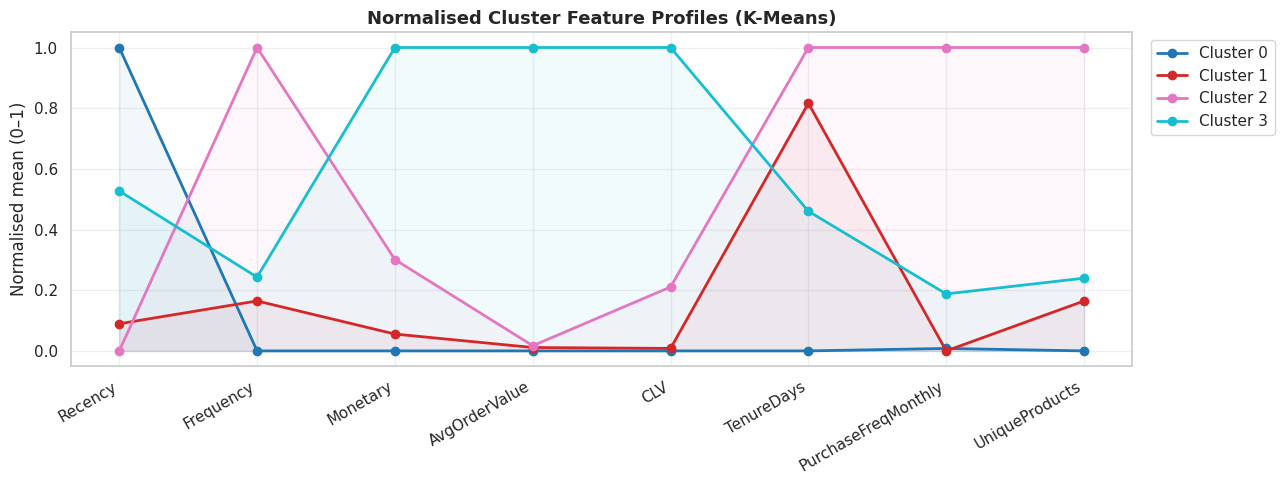


Cluster raw means:
         Recency  Frequency  Monetary  AvgOrderValue       CLV  TenureDays  PurchaseFreqMonthly  UniqueProducts
Cluster                                                                                                        
0           74.1        9.7   13872.4         1448.1   20499.2       254.0                  1.2             9.7
1           19.1       12.6   19202.5         1530.1   21466.5       327.9                  1.2            12.7
2           13.7       27.4   42772.5         1573.6   45354.7       344.5                  2.4            27.6
3           45.6       14.0  109879.4         8789.0  138444.5       295.7                  1.4            14.0


In [10]:
rfm_copy = rfm.copy()
rfm_copy['Cluster'] = km_labels

PROFILE_FEATURES = ['Recency','Frequency','Monetary',
                    'AvgOrderValue','CLV','TenureDays',
                    'PurchaseFreqMonthly','UniqueProducts']
available = [f for f in PROFILE_FEATURES if f in rfm_copy.columns]

means = rfm_copy.groupby('Cluster')[available].mean()
norm  = (means - means.min()) / (means.max() - means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(13, 5))
cmap2 = plt.get_cmap('tab10', K)
for i, row in norm.iterrows():
    ax.plot(available, row.values, marker='o', label=f'Cluster {i}',
            linewidth=2, color=cmap2(i))
    ax.fill_between(range(len(available)), row.values, alpha=0.06, color=cmap2(i))

ax.set_title('Normalised Cluster Feature Profiles (K-Means)', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(available)))
ax.set_xticklabels(available, rotation=30, ha='right')
ax.set_ylabel('Normalised mean (0–1)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_cluster_profiles.png', dpi=150)
plt.show()

print('\nCluster raw means:')
print(means.round(1).to_string())


## 10. Assign business labels & save

In [11]:
# Inspect cluster ordering by Monetary to assign meaningful names
order = means['Monetary'].sort_values(ascending=False)
print('Clusters by avg spend (helps assign labels):')
print(order.round(0).to_string())

# ─── Adjust this mapping after inspecting the table above ─────────────
CLUSTER_NAMES = {
    0: 'Champions',
    1: 'At-Risk Customers',
    2: 'Potential Loyalists',
    3: 'Hibernating',
}
# ──────────────────────────────────────────────────────────────────────

rfm['Cluster']      = km_labels
rfm['Cluster_Name'] = rfm['Cluster'].map(CLUSTER_NAMES).fillna('Other')

# Business summary table
summary = (
    rfm.groupby('Cluster_Name')
    .agg(
        Customers     = ('Recency',       'count'),
        Avg_Recency   = ('Recency',       'mean'),
        Avg_Frequency = ('Frequency',     'mean'),
        Total_Revenue = ('Monetary',      'sum'),
        Avg_CLV       = ('CLV',           'mean'),
        Avg_AOV       = ('AvgOrderValue', 'mean'),
    )
    .round(1)
    .sort_values('Total_Revenue', ascending=False)
)
print('\n=== CLUSTER BUSINESS SUMMARY ===')
print(summary.to_string())


Clusters by avg spend (helps assign labels):
Cluster
3    109879.0
2     42772.0
1     19202.0
0     13872.0

=== CLUSTER BUSINESS SUMMARY ===
                     Customers  Avg_Recency  Avg_Frequency  Total_Revenue   Avg_CLV  Avg_AOV
Cluster_Name                                                                                
At-Risk Customers         1959         19.1           12.6     37617652.2   21466.5   1530.1
Potential Loyalists        567         13.7           27.4     24251981.5   45354.7   1573.6
Champions                  620         74.1            9.7      8600894.3   20499.2   1448.1
Hibernating                  9         45.6           14.0       988914.2  138444.5   8789.0


In [12]:
# Save clustered feature matrix
rfm.to_csv(PROC_DIR / 'rfm_clustered.csv')

# Save production model + PCA reducer
joblib.dump(km_model,  MODEL_DIR / 'kmeans_model.pkl')
joblib.dump(pca2,      MODEL_DIR / 'pca_transformer.pkl')

print('Saved:')
print('  data/processed/rfm_clustered.csv')
print('  models/kmeans_model.pkl')
print('  models/pca_transformer.pkl')
print('  (scaler.pkl and feature_names.pkl saved in notebook 02)')


Saved:
  data/processed/rfm_clustered.csv
  models/kmeans_model.pkl
  models/pca_transformer.pkl
  (scaler.pkl and feature_names.pkl saved in notebook 02)


## 11. Revenue concentration (Pareto by cluster)

Segment                           Revenue    Share
--------------------------------------------------
At-Risk Customers            £37,617,652   52.6%  █████████████████████
Potential Loyalists          £24,251,982   33.9%  █████████████
Champions                    £ 8,600,894   12.0%  ████
Hibernating                  £   988,914    1.4%  


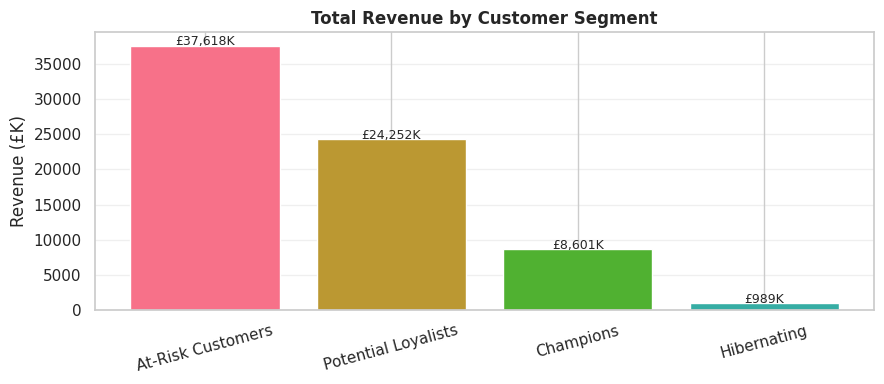

In [13]:
rev_by_cluster = (rfm.groupby('Cluster_Name')['Monetary']
                  .sum().sort_values(ascending=False))
total = rev_by_cluster.sum()

print(f'{"Segment":<28} {"Revenue":>12} {"Share":>8}')
print('-'*50)
for seg, rev in rev_by_cluster.items():
    bar = '█' * int(rev/total * 40)
    print(f'{seg:<28} £{rev:>10,.0f}  {rev/total:>6.1%}  {bar}')

fig, ax = plt.subplots(figsize=(9, 4))
colors = [f'C{i}' for i in range(len(rev_by_cluster))]
bars = ax.bar(rev_by_cluster.index, rev_by_cluster.values / 1e3,
              color=colors, edgecolor='white')
for bar, val in zip(bars, rev_by_cluster.values / 1e3):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'£{val:,.0f}K', ha='center', fontsize=9)
ax.set_title('Total Revenue by Customer Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (£K)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / '17_revenue_by_cluster.png', dpi=150)
plt.show()
